In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import datetime
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from utils import get_hpi

In [2]:
data = pd.read_csv('../data/merged.csv')

postcode_encoder = LabelEncoder()
data['Postcode_encoded'] = postcode_encoder.fit_transform(data['Postcode'].astype(str))

city_encoder = LabelEncoder()
data['City_encoded'] = city_encoder.fit_transform(data['City'].astype(str))

data['SoldDate'] = data['SoldDate'].str.replace('/span', '', regex=False)
data['SoldDate'] = pd.to_datetime(data['SoldDate'], format='%d-%b-%y', errors='coerce')
data.dropna(subset=['SoldDate'], inplace=True)
data['SoldYear'] = data['SoldDate'].dt.year

invalid_dates = data[data['SoldDate'].isna()]
print(invalid_dates[['SoldDate', 'Price', 'Postcode', 'City']])

data['Price'] = pd.to_numeric(data['Price'], errors='coerce')

# Drop rows where Price could not be converted (i.e. NaN)
data.dropna(subset=['Price'], inplace=True)

Empty DataFrame
Columns: [SoldDate, Price, Postcode, City]
Index: []


In [3]:
data['SaleHPI'] = data['SoldYear'].apply(get_hpi)
data['CurrentHPI'] = 1.00  # 2024 is our baseline
data['InflationFactor'] = data['CurrentHPI'] / data['SaleHPI']

# 6. Create a new column for the adjusted price
data['Price_Adjusted2024'] = data['Price'] * data['InflationFactor']

# 7. Now define X and y for modeling
#    (Here, you could choose 'Price_Adjusted2024' or 'Price' as your target, 
#     depending on whether you want to train on inflation-adjusted values.)

y = data['Price_Adjusted2024'].values
X = data[['City_encoded']] 

print(f"Number of rows in X: {X.shape[0]}")
print(f"Number of rows in y: {y.shape[0]}")

Number of rows in X: 52789
Number of rows in y: 52789


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train_log = np.log1p(y_train) 
y_test_log = np.log1p(y_test)


In [4]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=[X_train.shape[1]]),
    layers.Dropout(0.2), # regularization
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2), # regularization
    layers.Dense(1)
])


NameError: name 'X_train' is not defined

In [28]:
model.compile(
    optimizer='adam',
    loss='mse',       # Mean Squared Error for regression
    metrics=['mae'],   # Mean Absolute Error as a metric
)

# Train

In [29]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Fit the model
history = model.fit(
    X_train, 
    y_train_log,
    validation_split=0.2,   
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop], # to prevent overfitting
)

Epoch 1/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 1s 383us/step - loss: 205.2021 - mae: 10.1671 - val_loss: 41.6340 - val_mae: 5.2622
Epoch 2/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step - loss: 41.4512 - mae: 5.4372 - val_loss: 5.8642 - val_mae: 2.0917
Epoch 3/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step - loss: 9.6767 - mae: 2.4709 - val_loss: 3.0164 - val_mae: 1.5939
Epoch 4/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 0s 318us/step - loss: 5.6026 - mae: 1.8809 - val_loss: 0.4442 - val_mae: 0.5291
Epoch 5/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 0s 352us/step - loss: 3.9379 - mae: 1.5787 - val_loss: 0.3838 - val_mae: 0.4916
Epoch 6/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 0s 316us/step - loss: 2.8936 - mae: 1.3543 - val_loss: 0.3076 - val_mae: 0.4371
Epoch 7/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 0s 316us/step - loss: 2.1714 - mae: 1.1718 - val_loss: 0.3488 - val_mae: 0.4659
Epoch 8/50
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step - loss: 1.8333 - mae: 1.0723 - val_loss: 0.3567 - val_mae: 0.4715
Epoch 9/50
1056/105

# Evaluate

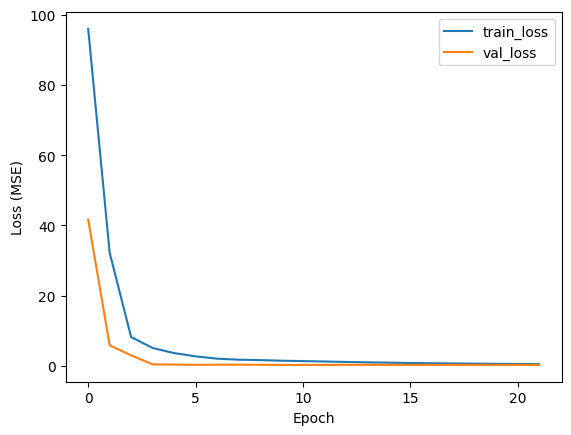

In [30]:
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [32]:
test_loss, test_mae = model.evaluate(X_test, y_test_log)
print(f"Test MSE: {test_loss:.2f}, Test MAE: {test_mae:.2f}")

y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)


330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 198us/step - loss: 0.3012 - mae: 0.4278
Test MSE: 0.32, Test MAE: 0.43
330/330 ━━━━━━━━━━━━━━━━━━━━ 0s 211us/step


# Prediction check

In [34]:
print("\nSample predictions vs. actual:")
for i in range(5):
    print(f"Predicted: {y_pred[i][0]:.2f}, Actual: {y_test[i]:.2f}")

    def predict_price(city):
        # Encode city
        encoded_city = city_encoder.transform([str(city)])[0]
        
        # Combine them into a single input
        input_data = np.array([[encoded_city]], dtype='float32')
        
        # The model outputs log(price + 1), so we exponentiate to get back to normal scale
        predicted_log_price = model.predict(input_data)  # shape = (1, 1)
        predicted_price = np.expm1(predicted_log_price)[0][0]  # invert the log transform
    
        return predicted_price

# Example usage:
sample_city = "Adelaide"
price_pred = predict_price(sample_city)
print(f"Predicted Price for (City={sample_city}): ${price_pred:,.2f}")


Sample predictions vs. actual:
Predicted: 795966.50, Actual: 1230434.75
Predicted: 795419.38, Actual: 402352.94
Predicted: 795966.50, Actual: 421176.47
Predicted: 613694.56, Actual: 649484.56
Predicted: 794740.00, Actual: 1328282.88
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Predicted Price for (City=Adelaide): $604,485.56
